# Inicios de MAC

##  Planteamiento

La premisa inicial y por la cual se inicia este proyecto es para que por medio de los datos que se han registrado en el 2024 y lo corrido en el 2025 de los procedimientos IVE se encuentren las variables que puedan darnos indicios si se va a iniciar o no el metodo de anticoncepción MAC. Se espera que con los modelos desarrollados alcanzar un 85% como minimo requerido de acertividad.
Dada la complejidad y el nivel técnico actual se llevara a cabo la validación por medio de tres modelos de aprendizaje supervisado:

    - Logistic Regression
    - Decision Tree Classifier
    - Random Forest Classifier 

# Conociendo la data

En esta etapa realizamos la importacion de bibliotecas, la conexión a la base de datos y la consulta, luego la transformamos en un dataframe el cual podemos manipular

In [1]:
from sqlalchemy import create_engine
import pandas as pd
import numpy as np 
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.io as pio
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score
from sklearn.exceptions import UndefinedMetricWarning
import warnings
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

pio.templates.default = 'plotly_dark'

In [2]:
# Conexión a la base de datos 

server = '192.168.10.13'
database = 'OPTIONS_DB'
username = 'adm_drodriguez'
password = '0r13nt4m3_4**'

engine = create_engine(f'mssql+pyodbc://{username}:{password}@{server}/{database}?driver=ODBC+Driver+17+for+SQL+Server')

# Lectura de consulta y conversión en un dataframe
df = pd.read_sql("""SELECT 
                    *,
                    dbo.Fun_ORI_CalculaEdad(B.FechaNacimiento,A.Fechaprocedimiento) Edad
                 FROM [DWH_servicios_clinicos] A 
                 LEFT JOIN  (SELECT
                                PK_Paciente,
                                FechaNacimiento
                            FROM [dbo].[dim_consultantes]) B ON A.Paciente = B.PK_Paciente
                 WHERE PK_FechaEventoPrincipal > '2023-12-31 23:59:59' 
                    AND TipoEvento LIKE '%IVE%' AND Desercion = 0""", engine)
df.head()

,Id,TipoEvento,QTY_evento,PK_FechaEventoPrincipal,Paciente,SedeID_PE,ServicioID_PE,responsableID_PE,meta_PE,FechaSolicitud,...,DX_1,DX_2,DX_3,DX_4,DX_5,LogConsultas,LogFechaProcedimiento,PK_Paciente,FechaNacimiento,Edad
0,40026,IVE,1,2025-07-30 15:44:20.163,76,3,129,3,3a2025m7,2025-07-26 11:22:00,...,None,None,None,None,None,OK,None,76.0,1994-10-30,30.0
1,12740,IVE,1,2024-10-29 09:24:43.287,166,1,129,44,1a2024m10,2024-10-29 08:35:00,...,None,None,None,None,None,OK,None,166.0,1986-02-10,38.0
2,41173,IVE,1,2025-08-25 12:16:29.583,167,1,100,3,1a2025m8,2025-08-25 11:34:00,...,None,None,None,None,None,OK,None,167.0,1996-10-19,28.0
3,30417,IVE,1,2025-03-29 12:14:15.570,294,1,100,3,1a2025m3,2025-03-27 11:27:00,...,None,None,None,None,None,OK,None,294.0,1993-09-25,31.0
4,12614,IVE,1,2024-01-20 11:21:11.397,307,1,100,3,1a2024m1,2024-01-19 12:29:00,...,None,None,None,None,None,OK,None,307.0,2004-10-23,19.0


In [3]:
# Validación de tipos de columnas 

df.head()

,Id,TipoEvento,QTY_evento,PK_FechaEventoPrincipal,Paciente,SedeID_PE,ServicioID_PE,responsableID_PE,meta_PE,FechaSolicitud,...,DX_1,DX_2,DX_3,DX_4,DX_5,LogConsultas,LogFechaProcedimiento,PK_Paciente,FechaNacimiento,Edad
0,40026,IVE,1,2025-07-30 15:44:20.163,76,3,129,3,3a2025m7,2025-07-26 11:22:00,...,None,None,None,None,None,OK,None,76.0,1994-10-30,30.0
1,12740,IVE,1,2024-10-29 09:24:43.287,166,1,129,44,1a2024m10,2024-10-29 08:35:00,...,None,None,None,None,None,OK,None,166.0,1986-02-10,38.0
2,41173,IVE,1,2025-08-25 12:16:29.583,167,1,100,3,1a2025m8,2025-08-25 11:34:00,...,None,None,None,None,None,OK,None,167.0,1996-10-19,28.0
3,30417,IVE,1,2025-03-29 12:14:15.570,294,1,100,3,1a2025m3,2025-03-27 11:27:00,...,None,None,None,None,None,OK,None,294.0,1993-09-25,31.0
4,12614,IVE,1,2024-01-20 11:21:11.397,307,1,100,3,1a2024m1,2024-01-19 12:29:00,...,None,None,None,None,None,OK,None,307.0,2004-10-23,19.0


In [4]:
# Visulaización de columnas con valores nulos

nulos = df.isnull().sum()
print(nulos[nulos > 0])

FK_antecedente                   8066
FK_consulta                       851
FK_orientacion                   2248
EdadGestacionalConsulta          1972
Profesional_PE                    412
FK_procedimiento                 4148
FK_recuperacion                 17372
EdadGestacionalProcedimiento      508
Profesional_SE                    412
SedeID_TE                        2145
FechaEventoMAC                   2128
EventoMAC                        2128
MAC_elegido                      2128
MAC_inicio                       2135
RazonNoEleccion                 20168
RegistroHCEMac                   2128
Profesional_Mac                  2128
FechaControlPost_1              13908
ExitoControlPost_1              15825
Conducta_1                      13909
Sangrado_1                      16451
Dolor_1                         16451
SedeControl_1                   13916
Profesional_Ctrl_1              13908
FechaControlPost_2              20014
ExitoControlPost_2              20218
Conducta_2  

In [5]:
# Creamos un dataframe copia del primero y lo llamamos df_mac con las columnas que consideremos necesarias para el modelo 

df_mac = df[['TipoEvento', 'QTY_evento', 'PK_FechaEventoPrincipal','Paciente','Edad',
             'EdadGestacionalProcedimiento','Desercion','TipoProcedimiento',
             'ModalidadProcedimiento', 'FechaProcedimiento','VlrFactura', 'SedeID_TE',
             'FechaEventoMAC','EventoMAC', 'MAC_elegido',
             'MAC_inicio', 'RazonNoEleccion', 'IndicadorTipoInicio']]

# Columnas para realizar el sunburst

df_mac['TipoProcedimientoo'] = df_mac['TipoProcedimiento']
df_mac['ModalidadProcedimientoo'] = df_mac['ModalidadProcedimiento']
df_mac['MAC_inicioo'] = df_mac['MAC_inicio']

In [6]:
df_mac.head()

,TipoEvento,QTY_evento,PK_FechaEventoPrincipal,Paciente,Edad,EdadGestacionalProcedimiento,Desercion,TipoProcedimiento,ModalidadProcedimiento,FechaProcedimiento,...,SedeID_TE,FechaEventoMAC,EventoMAC,MAC_elegido,MAC_inicio,RazonNoEleccion,IndicadorTipoInicio,TipoProcedimientoo,ModalidadProcedimientoo,MAC_inicioo
0,IVE,1,2025-07-30 15:44:20.163,76,30.0,9,False,IVE TM,PRS,2025-08-13,...,3.0,2025-08-27 09:16:46.680,Control post aborto,Preservativo para pene,Si,NaN,No Iniciado,IVE TM,PRS,Si
1,IVE,1,2024-10-29 09:24:43.287,166,38.0,4,False,IVE TM,PRS,2024-10-29,...,1.0,2024-10-29 10:21:25.177,Interrupción Voluntaria del Embarazo menor a 9...,Anticonceptivos inyectables combinados (AIC) (...,Si,NaN,Criterio OMS,IVE TM,PRS,Si
2,IVE,1,2025-08-25 12:16:29.583,167,28.0,4,False,IVE TM,PRS,2025-08-25,...,1.0,2025-08-25 14:38:42.870,Interrupción Voluntaria del Embarazo menor a 9...,Anticonceptivos inyectables progesterona (AIPS...,Si,NaN,Criterio OMS,IVE TM,PRS,Si
3,IVE,1,2025-03-29 12:14:15.570,294,31.0,8,False,IVE TM,PRS,2025-03-29,...,1.0,2025-03-29 12:14:15.570,Consulta de gestación no deseada - END,DIU Tcu (10),No,NaN,No Iniciado,IVE TM,PRS,No
4,IVE,1,2024-01-20 11:21:11.397,307,19.0,4.00,False,IVE TM,TLM,2024-01-20,...,1.0,2024-01-20 11:21:11.397,Consulta de gestación no deseada - END,DIU Tcu (10),No,NaN,No Iniciado,IVE TM,TLM,No


In [7]:
# Codificación de los MAC elegidos 

df_mac['MAC_elegido_encoded'] = LabelEncoder().fit_transform(df_mac['MAC_elegido'])

In [8]:
nulos = df_mac.isnull().sum()
print(nulos[nulos > 0])

Edad                             1191
EdadGestacionalProcedimiento      508
SedeID_TE                        2145
FechaEventoMAC                   2128
EventoMAC                        2128
MAC_elegido                      2128
MAC_inicio                       2135
RazonNoEleccion                 20168
MAC_inicioo                      2135
dtype: int64


In [9]:
# Metodo para el saber Moda, Medio y promedio de una columna númerica del dataframe

Moda= df_mac['Edad'].mode()
Media= df_mac['Edad'].median()
Promedio= df_mac['Edad'].mean()
print(f'Edad de las consultantes: \n\n Media: {Media} \n Promedio: {Promedio} \n Moda: {Moda} \n') 

Edad de las consultantes: 

 Media: 26.0 
 Promedio: 27.103685945459993 
 Moda: 0    25.0
Name: Edad, dtype: float64 



In [10]:
# Trabajo con los nulos y el como se van a llenar

df_mac['EdadGestacionalProcedimiento'].fillna('6',inplace=True) #Elegi el 6 ya que es la moda de esta columna
df_mac['MAC_inicio'].fillna('No',inplace=True) #Elegi No porque y el si se debe llenar obligatoriamente en la HC
df_mac['RazonNoEleccion'].fillna('No responde',inplace=True) #Elegi esta opción porque es omisión del enfemero al llenarlo en la HC 
df_mac['EventoMAC'].fillna('Interrupción Voluntaria del Embarazo',inplace=True) #Elegi esta opción ya que desde un inicio se elgio solo tipo de evento el IVE
df_mac['SedeID_TE'].fillna(1.,inplace=True) # Elegi esta opción ya que al ser presencial o telemedicina la moda es la sede 1 es decir teusaquillo
df_mac['Edad'].fillna(df_mac['Edad'].median(), inplace=True)


C:\Users\ddrodriguez\AppData\Local\Temp\ipykernel_2796\4029472330.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_mac['EdadGestacionalProcedimiento'].fillna('6',inplace=True) #Elegi el 6 ya que es la moda de esta columna
C:\Users\ddrodriguez\AppData\Local\Temp\ipykernel_2796\4029472330.py:4: ChainedAssignmentError: A value is 

0        30.0
1        38.0
2        28.0
3        31.0
4        19.0
         ... 
21208    26.0
21209    26.0
21210    26.0
21211    26.0
21212    26.0
Name: Edad, Length: 21213, dtype: float64

In [11]:
#Trabajo con los cambios de tipo en las columnas necesarias

df_mac['EdadGestacionalProcedimiento'] = pd.to_numeric(df_mac['EdadGestacionalProcedimiento'],errors='coerce') # Creo que impacta directamente en la elección de MAC
df_mac['EdadGestacionalProcedimiento'].fillna(6,inplace=True)
df_mac['TipoProcedimiento'] = df_mac['TipoProcedimiento'].map({"IVE TM":1,"IVE TQ":2,"TAI TQ":3,"PROCED":1,"TAI TM":4})
df_mac['ModalidadProcedimiento'] =df_mac['ModalidadProcedimiento'].map({"PRS":1,"TES":2,"TLM":3})
df_mac['MAC_inicio'] = df_mac['MAC_inicio'].map({"Si":1,"No":2,"No ":2})
df_mac['MAC_inicioo'] = df_mac['MAC_inicio']
df_mac['MAC_inicioo'] = df_mac['MAC_inicioo'].map({1:"Si",2:"No"})

C:\Users\ddrodriguez\AppData\Local\Temp\ipykernel_2796\1439732773.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_mac['EdadGestacionalProcedimiento'].fillna(6,inplace=True)


In [12]:
df_mac = df_mac.query("EdadGestacionalProcedimiento < 25 & VlrFactura < 999999 & Edad > 1")

In [13]:
df_mac['PK_FechaEventoPrincipal'] = pd.to_datetime(df_mac['PK_FechaEventoPrincipal']).dt.date
df_mac['FechaProcedimiento'] = pd.to_datetime(df_mac['FechaProcedimiento']).dt.date
df_mac['FechaEventoMAC'] = pd.to_datetime(df_mac['FechaEventoMAC']).dt.date

# EDA (Analisis exploratorio de los datos)

Se visualizaran los datos del dataframe al cual se le realizo la limpieza con el objetivo de encontrar ademas de insights posibles relaciones o features que se utilizaran en los modelo 

## EDA todos los procedimientos

In [14]:
np.round(df_mac.describe(),0)

,QTY_evento,Paciente,Edad,EdadGestacionalProcedimiento,TipoProcedimiento,ModalidadProcedimiento,VlrFactura,SedeID_TE,MAC_inicio,MAC_elegido_encoded
count,18429.0,18429.0,18429.0,18429.0,18429.0,18429.0,18429.0,16980.0,16989.0,18429.0
mean,1.0,43852.0,27.0,7.0,1.0,1.0,511002.0,4.0,1.0,7.0
std,0.0,15022.0,7.0,2.0,0.0,1.0,136300.0,4.0,0.0,5.0
min,1.0,76.0,3.0,0.0,1.0,1.0,45000.0,1.0,1.0,0.0
25%,1.0,32427.0,22.0,5.0,1.0,1.0,399000.0,1.0,1.0,4.0
50%,1.0,44231.0,26.0,6.0,1.0,1.0,465000.0,2.0,1.0,5.0
75%,1.0,56119.0,31.0,7.0,1.0,2.0,510000.0,7.0,2.0,9.0
max,1.0,68489.0,85.0,24.0,4.0,3.0,993000.0,17.0,2.0,18.0


In [15]:
columns = ['EdadGestacionalProcedimiento','Edad','VlrFactura']

for column in columns:
    fig = px.histogram(df_mac,column, title=f'Histograma of {column}', marginal= 'violin')
    fig.show()

In [16]:
columns = ['EdadGestacionalProcedimiento','Edad','VlrFactura']

for column in columns:
    fig = px.histogram(df_mac,column,color='MAC_inicioo', title=f'Histograma of {column}', marginal= 'violin')
    fig.show()

In [17]:
ive = df_mac['TipoProcedimiento'].value_counts()

fig = px.bar(ive,color=ive.index, title = "Cantidad de eventos por categoria")
fig.update_xaxes(
        title_text = "Tipo de procedimiento",
        ticktext = ['IVE TM','IVE TQ','TAI TM','TAI TQ'],
        tickvals = [1,2,3,4]
)
fig.show()

In [18]:
a = df_mac['MAC_inicio'].value_counts()

fig = px.pie(names=a.index,values=a.values, title = "Porcentaje de inicios de MAC", hole=0.3)
fig.update_traces(labels = ['Si', 'No'],
                  textinfo = 'text+percent')
fig.show()


In [19]:
pivot = pd.pivot_table(df_mac, index='PK_FechaEventoPrincipal',columns='TipoProcedimiento', values='QTY_evento',aggfunc='count', fill_value=0).rename(columns={1:'IVE TM',2:'IVE TQ',3:'TAI TM',4:'TAI TQ'})

fig = px.line(pivot, title="Cantidad de Procedimientos por rango de fecha")
fig.update_xaxes(title_text = "Fecha Procedimiento")
fig.update_yaxes(title_text = "Cantidad",
)


In [20]:
fig = px.sunburst(df_mac,path=['MAC_inicioo','ModalidadProcedimientoo','TipoProcedimientoo','RazonNoEleccion'],
                  values='QTY_evento',color_continuous_scale='diviris',
                  title="Razon de No eleccion inicio MAC")
fig.show()

ValueError: ('None entries cannot have not-None children', ('Si', 'TLM', 'IVE TM', nan))

In [21]:
edades = ['Edad','EdadGestacionalProcedimiento','TipoProcedimiento','MAC_elegido_encoded']

for edad in edades:
    fig = px.scatter(df_mac, x=edad, y='VlrFactura',trendline='ols',color='TipoProcedimientoo', title=f'Relación entre {edad} y Valor de factura'  )
    fig.show()

ModuleNotFoundError: No module named 'statsmodels'

<Axes: >

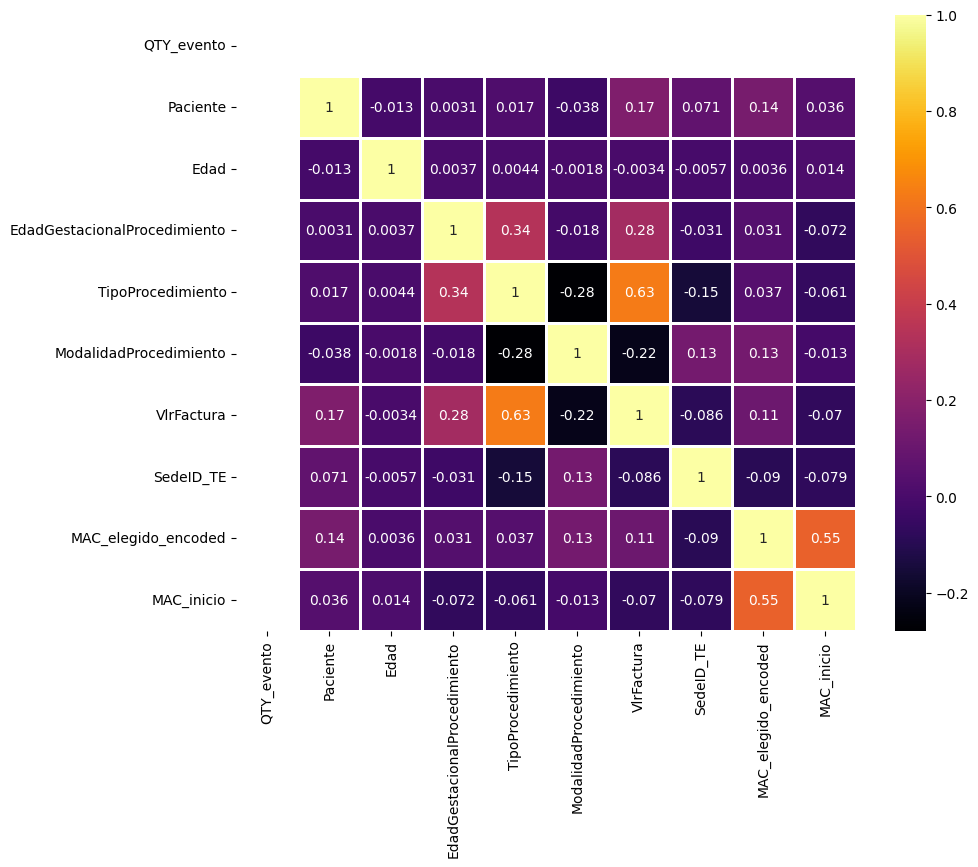

In [22]:
corr = df_mac[['QTY_evento','Paciente','Edad','EdadGestacionalProcedimiento','TipoProcedimiento','ModalidadProcedimiento','VlrFactura','SedeID_TE','MAC_elegido_encoded','MAC_inicio']]

plt.figure(figsize=(10,8))
sns.heatmap(corr.corr(), linecolor="white", linewidths=2, annot=True, cmap='inferno')

## EDA Inicios de MAC negativos

In [23]:
df_no = df_mac.query('MAC_inicio == 2')
df_no.head(5)

,TipoEvento,QTY_evento,PK_FechaEventoPrincipal,Paciente,Edad,EdadGestacionalProcedimiento,Desercion,TipoProcedimiento,ModalidadProcedimiento,FechaProcedimiento,...,FechaEventoMAC,EventoMAC,MAC_elegido,MAC_inicio,RazonNoEleccion,IndicadorTipoInicio,TipoProcedimientoo,ModalidadProcedimientoo,MAC_inicioo,MAC_elegido_encoded
3,IVE,1,2025-03-29,294,31.0,8.0,False,1,1,2025-03-29,...,2025-03-29,Consulta de gestación no deseada - END,DIU Tcu (10),2.0,NaN,No Iniciado,IVE TM,PRS,No,8
4,IVE,1,2024-01-20,307,19.0,4.0,False,1,3,2024-01-20,...,2024-01-20,Consulta de gestación no deseada - END,DIU Tcu (10),2.0,NaN,No Iniciado,IVE TM,TLM,No,8
8,IVE,1,2024-10-12,351,21.0,6.0,False,1,1,2024-10-12,...,2024-10-12,Consulta de gestación no deseada - END,DIU Tcu (10),2.0,NaN,No Iniciado,IVE TM,PRS,No,8
10,IVE,1,2026-01-23,418,25.0,6.0,False,1,1,2026-01-23,...,2026-01-23,Consulta de gestación no deseada - END,Anticonceptivos inyectables combinados (AIC) (...,2.0,NaN,No Iniciado,IVE TM,PRS,No,4
11,IVE,1,2025-10-08,427,35.0,5.0,False,1,1,2025-10-08,...,2025-10-22,Control post aborto,DIU Tcu (10),2.0,NaN,No Iniciado,IVE TM,PRS,No,8


In [24]:
MAC = df_no['MAC_elegido'].value_counts()

fig = px.bar(MAC, title="MAC elegidos")
fig.show()

In [25]:
mod = df_no['ModalidadProcedimiento'].value_counts()

fig = px.pie(values=mod.values,names=mod.index, title="No inicios de MAC por modalidad")
fig.update_traces(labels = ['PRS','TLM','TES'],
                  textinfo = 'text+percent')
fig.show()

In [26]:
columns = ['EdadGestacionalProcedimiento','Edad','VlrFactura']

for column in columns:
    fig = px.histogram(df_no,column, title=f' Distribución de {column} no inicio MAC', marginal= 'violin')
    fig.show()

# Modelos de ML
## Features

Para la realización de los modelos se eligion las siguientes variables:

- Edad
    - Rango desde 4 hasta 60 debe ser entero
- Edad gestacional procedimiento
    - Rango desde 0 hasta 24 puede ser un numero decimal
- Tipo procedimiento

    - IVE TM: 1
    - IVE TQ: 2
    - TAI TQ: 3
    - PROCED: 1
    - TAI TM: 4

- Modalidad procedimiento

    - PRS: 1
    - TES: 2
    - TLM: 3

- Valor de la factura
    - Rango desde 79000 hasta 995000
- Id de la sede

    - TEUSAQUILLO:  1
    - USAQUEN: 2
    - SUBA: 3
    - MEDELLIN: 4
    - BARRANQUILLA: 5
    - TUNAL: 7
    - DOSQUEDRADAS: 8
    - CUCUTA: 9
    - IPIALES: 10
    - VILLAVICENCIO: 11
    - VALLEDUPAR: 12
    - IBAGUE: 13
    - PIEDECUESTA: 14
    - TUNJA: 15
    - POPAYAN: 16
    - NEIVA: 17
    - TELEMEDICINA: 18


- MAC elegido

    - 'Anillo anticonceptivo combinado': 0
    - 'Anticonceptivos Orales combinados (AOC)': 1
    - 'Anticonceptivos Orales progesterona (AOPS)': 2
    - 'Anticonceptivos inyectables combinados (AIC) (Mensuales): 3
    - 'Anticonceptivos inyectables progesterona (AIPS) (Trimestral)': 4
    - 'DIU Hormonal Jaidess (3)': 5
    - 'DIU Hormonal Mirena (7)': 6
    - 'DIU Tcu (10)': 7
    - 'Esterilizacion Femenina': 8
    - 'Implante Subdérmico Implanon (3)': 9
    - 'Implante Subdérmico Jadelle (5)': 10
    - 'Implante Subdérmico Sinoimplant (4)': 11
    - 'Metodos Naturales':  12
    - 'Ninguno':  13
    - 'Otros': 14
    - 'Parche anticonceptivo combinado': 15
    - 'Preservativo para pene': 16

In [27]:
X = df_mac[['Edad','EdadGestacionalProcedimiento','TipoProcedimiento','ModalidadProcedimiento','VlrFactura','SedeID_TE','MAC_elegido_encoded']]
y = df_mac['MAC_inicioo']

X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=42, test_size=0.3)

print(f'X_train shape: ', X_train.shape)
print(f'X_test shape: ', X_test.shape)
print(f'y_train shape: ', y_train.shape)
print(f'y_test shape: ', y_test.shape)


X_train shape:  (12900, 7)
X_test shape:  (5529, 7)
y_train shape:  (12900,)
y_test shape:  (5529,)


## Regresion Logistica

 En este modelo linear encontre que no se esta contemplando la segunda clase que en mis datos por eso es que en la matriz de confusión no tengo, TN y TP seria las que no iniciaron MAC, no he tratado ninguna solución unicamente voy a crear modelos no lineales y observar si cambia de alguna forma el resultado

In [28]:
lrm = LogisticRegression(class_weight='balanced')

lrm.fit(X_train, y_train)
y_predic = lrm.predict(X_test)

print(f'accuracy: {accuracy_score(y_test,y_predic)}')
print(classification_report(y_test,y_predic))

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
confusion_matrix = metrics.confusion_matrix(y_test,y_predic)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = ["No inicio", "Inicio"])

# display matrix
cm_display.plot()
plt.show()

In [ ]:
#Features:'Edad','EdadGestacionalProcedimiento','TipoProcedimiento','ModalidadProcedimiento','VlrFactura','SedeID_TE','MAC_elegido_encoded'

feature = np.array([[37,5,1,1,465000,8,6]])

y_prediction = lrm.predict(feature)

print(y_prediction)

In [ ]:
df_mac.iloc[699]

In [ ]:
print("Unique predictions:", np.unique(y_predic))

## Random Forest Classifier

In [ ]:
rfc = RandomForestClassifier()

rfc.fit(X_train, y_train)

y_predic_rfc = rfc.predict(X_test)

print(f'accuracy: {accuracy_score(y_test,y_predic_rfc)}')
print(classification_report(y_test,y_predic_rfc))

In [ ]:
confusion_matrix = metrics.confusion_matrix(y_test,y_predic_rfc)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = ["No inicio", "Inicio"])

# display matrix
cm_display.plot()
plt.show()

In [ ]:
#Features:'Edad','EdadGestacionalProcedimiento','TipoProcedimiento','ModalidadProcedimiento','VlrFactura','SedeID_TE','MAC_elegido_encoded'

feature = np.array([[56,9,1,1,460000,1,1]])

y_prediction = rfc.predict(feature)

print(y_prediction)

In [ ]:
df_mac.iloc[3011]

In [ ]:
print("Unique predictions:", np.unique(y_predic_rfc))

## Decision Tree Classifier

In [ ]:
dtc = DecisionTreeClassifier()

dtc.fit(X_train, y_train)

y_predict_dtc = dtc.predict(X_test)

print(f'accuracy: {accuracy_score(y_test,y_predict_dtc)}')
print(classification_report(y_test,y_predict_dtc))

In [ ]:
confusion_matrix = metrics.confusion_matrix(y_test,y_predict_dtc)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = ["No inicio", "Inicio"])

# display matrix
cm_display.plot()
plt.show()

In [ ]:
#Features:'Edad','EdadGestacionalProcedimiento','TipoProcedimiento','ModalidadProcedimiento','VlrFactura','SedeID_TE','MAC_elegido_encoded'

feature = np.array([[23,4,1,2,399000,7,5]])

y_prediction = dtc.predict(feature)

print(y_prediction)

In [ ]:
df_mac.iloc[1509]